# Финальный проект модуля Python
#  «Анализ данных об оптовых продажах аудиотехники»

**Текст задания:** 

**В финальном проекте модуля Python вам предстоит поработать аналитиком данных в компании «Карпов Саунд», которая занимается оптовой продажей аудиотехники и предлагает широкий ассортимент товаров от ведущих мировых брендов, включающий профессиональные аудиосистемы, домашние кинотеатры, портативные аудиоустройства и прочие аксессуары.** 

«Карпов Саунд» сотрудничает с крупными розничными сетями и специализированными магазинами аудиотехники в России. Клиенты компании регулярно оставляют заявки на закупку товаров в CRM системе, менеджеры связываются с клиентами, обсуждают детали, после чего заказы либо подтверждаются менеджерами, либо по разным причинам отменяются. 

В «Карпов Саунд» трепетно относятся к хранению информации о своих товарах, клиентах и заказах, однако в самый неподходящий момент хранилище данных компании оказалось временно недоступно из-за плановых работ по его оптимизации. Поэтому в рамках этого проекта все данные будут представлены не в самом удобном для анализа виде — в формате резервной выгрузки, разложенной по разным папкам на сервере компании.

**Источник:** Karpov Courses

**Курс:** Аналитик данных, https://karpov.courses/analytics

1. В проекте я провела сбор данных из разрозненных источников и собрала информацию в три датасета для анализа
2. Определила дни с аномальными показателями и выявила причины этих явлений.
3. Провела расчет ключевых метрик: общая выручка, средний чек заказа, количество заказов. Проанализировала их изменения в динамике.
4. Выявила наиболее прибыльные для продажи бренды, а также товары, которые наиболее востребованы среди покупателей.
5. Выявила бренды, у которых больше половины товаров не популярны у покупателей и никогда не заказывались. Возможно, от их продажи на маркетплейсе есть смысл отказаться, так как они перегружают маркетплейс.

**В ходе работы над проектом использовались данные из следующих таблиц:**  

1) orders (данные о заказах):  
- order_id — номер заказа  
- product_id — идентификатор товара  
- quantity — количество этого товара в заказе

2) order_status (данные о статусах заказов и клиентах):
- order_id — номер заказа  
- client_id — идентификатор клиента  
- status — статус заказа

3) products (данные о товарах):
- id — идентификатор товара  
- name — имя товара (сначала указан бренд, через запятую модель товара)  
- price — цена единицы товара, в долларах

Каждый заказ имеет статус или подтвержденного (`confirmed`), или отмененного (`canceled`). В одном заказе может быть несколько разных товаров. Если заказ был отменен, а потом создан такой же (тем же клиентом, с теми же товарами, у того же менеджера), в базе останется запись о двух заказах с разными номерами и статусами, поскольку система не позволяет создать заказ с тем же номером.

Я собрала и предобработала три типа датасетов: `orders.csv`, `order_status.csv`, `products.csv`.

На схеме показано, как связаны таблицы между собой:

![](https://storage.yandexcloud.net/klms-public/production/learning-content/457/4167/37264/104636/497986/er_white.png)

## Работа с данными

Данные находятся в папке `data` из директории `shared` (`shared` -> `homeworks` -> `python_ds_miniprojects` -> `final_project`). Внутри папки `data` находятся 2 другие папки: `orders` и `products`.

В папке `orders` папки с датами, в которые сделаны записи. В этих папках — папки с именами менеджеров по продажам. Эти папки содержат файлы `orders.csv` и `order_status.csv` (в каждой папке по одной паре файлов). Пример структуры: `data` -> `orders` -> `2024-03-01` -> `Алексей Саксофонов` -> `orders.csv` и `order_status.csv`.

В папке `products` папки с категориями товаров. В этих папках файлы `products.csv` (в каждой папке по одному файлу). Пример структуры: `data` -> `products` -> `AV-процессор` -> `products.csv`.

Кроме того у вас есть файл `usd_rate.txt` с курсом доллара США на каждый день анализируемого периода (данные в формате `дата,курс,валюта`). Он потребуется в середине проекта.

### Сбор датасета с заказами по папкам

**Сбор данных со всех папок в три датафрейма:**  
1. `df_orders` — на основе датасетов `orders.csv` + добавьте колонку `manager` с именами менеджеров и колонку `date` с датами. Отсортируйте датафрейм по возрастанию `order_id` и `product_id`.
2. `df_order_status` — на основе датасетов `order_status.csv`. Отсортируйте датафрейм по возрастанию `order_id`. 
3. `df_products` — на основе датасетов `products.csv` + добавьте колонку `category` с категориями товаров. Отсортируйте датафрейм по возрастанию `id`.  

In [1]:
import pandas as pd
import os

In [2]:
way = "/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/"

In [3]:
import os

for path, dirs, files in os.walk(way):
    print(f"{path}---{dirs}---{files}")

/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/---['orders', 'products']---[]
/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/orders---['2024-03-29', '2024-03-22', '2024-03-09', '2024-03-15', '2024-03-12', '2024-03-11', '2024-03-07', '2024-03-13', '2024-03-03', '2024-03-04', '2024-03-19', '2024-03-28', '2024-03-17', '2024-03-18', '2024-03-27', '2024-03-05', '2024-03-23', '2024-03-08', '2024-03-14', '2024-03-10', '2024-03-20', '2024-03-02', '2024-03-01', '2024-03-21', '2024-03-16', '2024-03-24', '2024-03-26', '2024-03-25', '2024-03-31', '2024-03-30', '2024-03-06']---[]
/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-29---['Ксения Балалайкина', 'Алексей Саксофонов', 'Владимир Ударников', 'Антон Скрипкин', 'Анастасия Дудкина', 'Аркадии

In [4]:
for path, dirs, files in os.walk(f'/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/tree/shared/homeworks/python_ds_miniprojects/final_project/data'):
    for file in files:
        file_path = os.path.join(path, file)

In [5]:
file_paths = []
for path, dirs, files in os.walk(way):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(path, file)
            file_paths.append(file_path)

In [6]:
file_paths

['/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-29/Ксения Балалайкина/order_status.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-29/Ксения Балалайкина/orders.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-29/Алексей Саксофонов/order_status.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-29/Алексей Саксофонов/orders.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-29/Владимир Ударников/order_status.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-evgenija-hozhaj-rjl7953/shared/

In [7]:
df_orders = pd.DataFrame() 
df_order_status = pd.DataFrame()
df_products = pd.DataFrame()
for i in file_paths:
    if 'orders.csv' in i:
        data = pd.read_csv(i)
        data['manager'] = i.split('/')[-2]
        data['date'] = i.split('/')[-3]
        df_orders = pd.concat([df_orders, data], ignore_index=True) #сразу верные индексы в порядке возрастания
    elif 'order_status.csv' in i:
        data = pd.read_csv(i)
        df_order_status = pd.concat([df_order_status, data], ignore_index=True)
    elif 'products.csv' in i: 
        data = pd.read_csv(i)
        data['category'] = i.split('/')[-2]
        df_products = pd.concat([df_products, data], ignore_index=True)

**Вид таблицы df_orders**

In [8]:
df_orders

,order_id,product_id,quantity,manager,date
0,KTPS-97694869,630,8,Ксения Балалайкина,2024-03-29
1,KTPS-97694869,269,30,Ксения Балалайкина,2024-03-29
2,KTPS-97694869,273,44,Ксения Балалайкина,2024-03-29
3,KTPS-97694869,212,2,Ксения Балалайкина,2024-03-29
4,KTPS-97694869,162,19,Ксения Балалайкина,2024-03-29
...,...,...,...,...,...
4598,EWUD-39727928,756,30,Виктор Тромбонов,2024-03-06
4599,EWUD-39727928,1656,13,Виктор Тромбонов,2024-03-06
4600,EWUD-39727928,1408,7,Виктор Тромбонов,2024-03-06
4601,EWUD-39727928,476,13,Виктор Тромбонов,2024-03-06


Суммарное количество заказанных товаров из таблицы df_orders

In [9]:
df_orders.quantity.sum()

85062

**Вид таблицы df_order_status с информацией о статусе заказа**

Количество наименований заказов с информацией о сделавшем заказ клиенте - 346.

In [10]:
df_order_status.shape

(346, 3)

In [11]:
# первые 10 заказов

df_order_status.head(10)

,order_id,client_id,status
0,KTPS-97694869,53,confirmed
1,UBIM-42773287,49,confirmed
2,WOGM-38825674,75,confirmed
3,OFTC-18078865,87,confirmed
4,YYLS-02926898,47,confirmed
5,NXMY-65800106,92,confirmed
6,ZREY-28717532,22,confirmed
7,TOST-59074807,60,confirmed
8,HLPA-53369796,43,confirmed
9,WOOW-33203958,56,confirmed


**Вид таблицы df_products c наименованием продаваемых товаров, их ценой за единицу и категорией**

Количество наименований - 1677.

In [13]:
df_products.shape

(1677, 4)

In [14]:
df_products.head(10)

,id,name,price,category
0,12,"ART, DJPREII",41.58,Предусилитель
1,66,"Behringer, Microphono PP400",20.76,Предусилитель
2,114,"Cambridge Audio, Azur 851N",1275.03,Предусилитель
3,248,"Douk Audio, P2",64.90,Предусилитель
4,340,"Emotiva, BasX PT-100",246.89,Предусилитель
5,356,"Fosi Audio, P1 Tube",41.57,Предусилитель
6,357,"Fosi Audio, T20",86.60,Предусилитель
7,506,"Heco, Prelude 200",202.58,Предусилитель
8,507,"Heco, Prelude 300",336.26,Предусилитель
9,908,"Magnat, MR 760",630.44,Предусилитель


Сумма цен всех продаваемых товаров:

In [15]:
df_products.price.sum()

839000.25

### Посмотрим на общую динамику заказов и определим дни, которые выбиваются из общей картины

Провела расчет количества заказов в каждый день.

In [16]:
df_orders.date = pd.to_datetime(df_orders.date, format='%Y-%m-%d')

In [17]:
df_orders

,order_id,product_id,quantity,manager,date
0,KTPS-97694869,630,8,Ксения Балалайкина,2024-03-29
1,KTPS-97694869,269,30,Ксения Балалайкина,2024-03-29
2,KTPS-97694869,273,44,Ксения Балалайкина,2024-03-29
3,KTPS-97694869,212,2,Ксения Балалайкина,2024-03-29
4,KTPS-97694869,162,19,Ксения Балалайкина,2024-03-29
...,...,...,...,...,...
4598,EWUD-39727928,756,30,Виктор Тромбонов,2024-03-06
4599,EWUD-39727928,1656,13,Виктор Тромбонов,2024-03-06
4600,EWUD-39727928,1408,7,Виктор Тромбонов,2024-03-06
4601,EWUD-39727928,476,13,Виктор Тромбонов,2024-03-06


In [18]:
order_num = df_orders.groupby('date', as_index = False).order_id.nunique()\
    .sort_values('order_id', ascending = False)

In [19]:
order_num

,date,order_id
13,2024-03-14,34
12,2024-03-13,24
0,2024-03-01,22
28,2024-03-29,19
4,2024-03-05,18
26,2024-03-27,18
14,2024-03-15,17
25,2024-03-26,17
21,2024-03-22,16
11,2024-03-12,15


Наибольшее количество заказов было сделано **14 марта 2024 - 34 заказа**. Дата преобразована в формат гггг-мм-дд.

**Построение графиков с количеством заказов по дням и проверка их на сезонность.** 

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

(array([738945., 738946., 738950., 738954., 738958., 738962., 738966.,
        738970., 738974., 738977.]),
 <a list of 10 Text major ticklabel objects>)

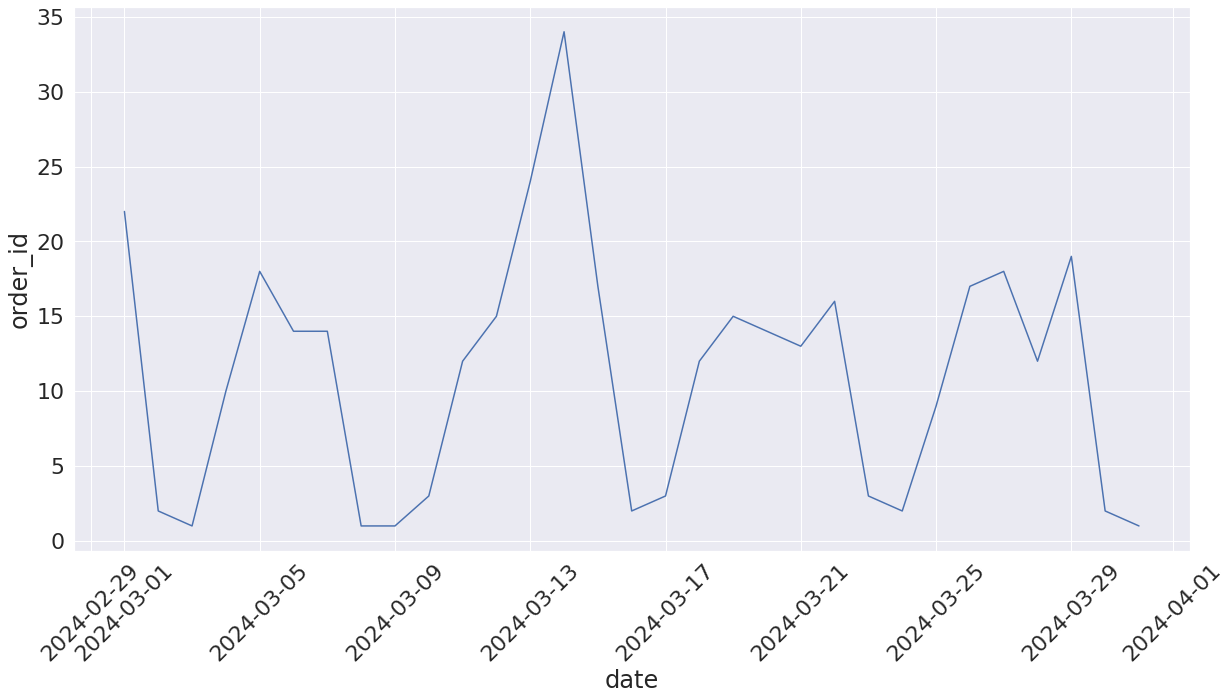

In [21]:
sns.set(font_scale = 2, rc = {'figure.figsize': (20,10)})
ax = sns.lineplot(data = order_num, x = 'date', y = 'order_id')
plt.xticks(rotation=45)

График за период с 29 февраля по 1 апреля дает основание предположить наличие недельной сезонности. В каждую неделю есть дни, когда заказов почти не бывает.

Я проверила на наличие сезонности по дням недели.

In [22]:
order_num['day'] = order_num.date.dt.day_name()

In [23]:
order_by_weekday = order_num.sort_values('date')

In [24]:
order_num.groupby('day', as_index = False).order_id	.sum().sort_values('order_id', ascending = False)

,day,order_id
0,Friday,75
4,Thursday,73
6,Wednesday,70
5,Tuesday,65
1,Monday,43
2,Saturday,10
3,Sunday,10


Если рассмотреть количество заказов за весь период по дням недели, можно отметить, что меньше всего было сделано заказов в субботу и воскресенье. 

In [25]:
order_by_weekday

,date,order_id,day
0,2024-03-01,22,Friday
1,2024-03-02,2,Saturday
2,2024-03-03,1,Sunday
3,2024-03-04,10,Monday
4,2024-03-05,18,Tuesday
5,2024-03-06,14,Wednesday
6,2024-03-07,14,Thursday
7,2024-03-08,1,Friday
8,2024-03-09,1,Saturday
9,2024-03-10,3,Sunday


В динамике по дням видно, что именно в субботу и воскресенье число сделанных заказов сокращается.

**Общий вывод:** Есть недельная сезонность в количестве совершаемых клиентами заказов. По выходным почти нет заказов.

**В данных помимо дня с наибольшим числом заказов есть еще один день, который выбивается из общей картины.**
 
- 8 марта, пятница. Обычно в пятницу довольно высокое количество заказов, но 8 марта был сделан только один. Это был праздничный день, клиенты не занимались покупкой музыкальных товаров.

## Выяснение причины резкого роста заказов в один из дней

К вам пришел руководитель отдела продаж и попросил выяснить причину, почему заказы в один из дней резко подскочили, чтобы и дальше увеличивать продажи. День резкого роста заказов, как было выявлено ранее, - **14 марта**.

Возможно, в день с наибольшим числом заказов отдел маркетинга запустил какую-то акцию? Или менеджеры стали активнее предлагать компаниям оформить заказ? Изучим подробнее этот день. 

In [27]:
df_orders_new = df_orders.merge(df_order_status, on = 'order_id', how = 'inner')
df_orders_new

,order_id,product_id,quantity,manager,date,client_id,status
0,KTPS-97694869,630,8,Ксения Балалайкина,2024-03-29,53,confirmed
1,KTPS-97694869,269,30,Ксения Балалайкина,2024-03-29,53,confirmed
2,KTPS-97694869,273,44,Ксения Балалайкина,2024-03-29,53,confirmed
3,KTPS-97694869,212,2,Ксения Балалайкина,2024-03-29,53,confirmed
4,KTPS-97694869,162,19,Ксения Балалайкина,2024-03-29,53,confirmed
...,...,...,...,...,...,...,...
4598,EWUD-39727928,756,30,Виктор Тромбонов,2024-03-06,28,confirmed
4599,EWUD-39727928,1656,13,Виктор Тромбонов,2024-03-06,28,confirmed
4600,EWUD-39727928,1408,7,Виктор Тромбонов,2024-03-06,28,confirmed
4601,EWUD-39727928,476,13,Виктор Тромбонов,2024-03-06,28,confirmed


Добавили к данным о заказах информацию об их статусах. Сохранили получившийся датафрейм в csv файл `orders_status.csv`.

In [28]:
df_orders_new.to_csv('orders_status.csv', index=False)

## Количество и соотношение подтвержденных и отмененных заказов

Посмотрела на количество и соотношение подтвержденных и отмененных заказов. **89%** - подтвержденные и **11%** отмененные.

In [30]:
df_orders_new.status.value_counts(normalize = True).round(2)

confirmed    0.89
canceled     0.11
Name: status, dtype: float64

## Количество подтвержденных и отмененных заказов на каждую дату

- В какой день не было ни одного подтвержденного заказа?  

In [31]:
count_by_status = df_orders_new.groupby(['date', 'status'], as_index = False).order_id.nunique().rename(columns = {'order_id': 'number'})
count_by_status

,date,status,number
0,2024-03-01,canceled,2
1,2024-03-01,confirmed,20
2,2024-03-02,confirmed,2
3,2024-03-03,confirmed,1
4,2024-03-04,confirmed,10
5,2024-03-05,confirmed,18
6,2024-03-06,canceled,1
7,2024-03-06,confirmed,13
8,2024-03-07,canceled,1
9,2024-03-07,confirmed,13


Сделала сводную таблицу, где в строках будут даты, в колонках — статусы заказов, а значения — число заказов с этим статусом в определенную дату.

In [32]:
count_by_status.pivot(values = 'number', index = 'date', columns = 'status').fillna(0) \
.astype('int')

status,canceled,confirmed
date,,
2024-03-01,2,20
2024-03-02,0,2
2024-03-03,0,1
2024-03-04,0,10
2024-03-05,0,18
2024-03-06,1,13
2024-03-07,1,13
2024-03-08,0,1
2024-03-09,1,0


In [33]:
count_by_status.pivot(values = 'number', index = 'date', columns = 'status').fillna(0) \
.astype('int') \
.query('confirmed == 0')

status,canceled,confirmed
date,,
2024-03-09,1,0


**Выяснила, что 9 марта не было ни одного подтвержденного заказа.**

## График с заказами по дням в разбивке по статусу заказа

**График с заказами по дням в разбивке по статусу заказа.**  Смотрим подробнее на день с наибольшим числом заказов (и подтвержденных, и отменных) - 14 марта и на день, предшествующий ему.

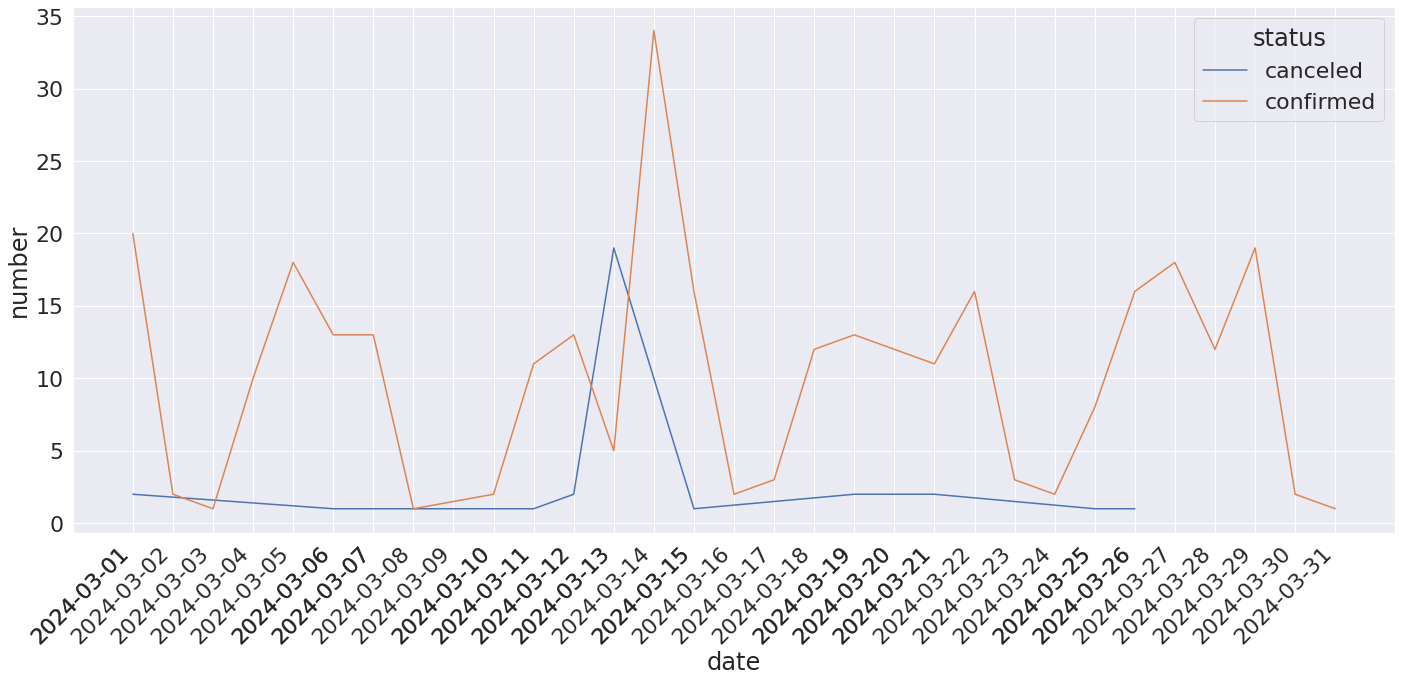

In [34]:
plt.figure(figsize=(20, 10))
ax = sns.lineplot(data=count_by_status, x="date", y="number", hue="status", markers = True) #сделали так, даты отобразились без пропусков
ax.set_xticks(count_by_status.date) #отображены все даты
plt.xticks(rotation=45, ha='right') #все выравнено по правому углу
plt.grid(True, which='both', linestyle='-', linewidth=1)
plt.tight_layout()

**Выводы:**
- В день с наибольшим числом заказов (14 марта) было много успешно оформленных заказов (34). 
- В предшествующий день было много отмен (19), тогда как подтвержденных 5.

## Анализирую причины такой ситуации с заказами 13 и 14 марта

Рассматриваю эти два дня отдельно (13 и 14 марта). На основе анализа проверяю, какая из двух гипотез наиболее правдоподобна. 

Гипотезы:
- Так сложилось, что один день оказался крайне неудачным для отдела продаж, все клиенты отменили свои заказы. А на следующий день отдел продаж пытался компенсировать отсутствие продаж в предыдущий и перевыполнил дневной план. Почти все заказы не повторяют вчерашние  
- Произошел сбой в работе CRM системы, который не позволил клиентам подтвердить заказ. В результате все созданные в первый день заказы автоматически отменились, поэтому клиентам пришлось оформлять их повторно на следующий день. Почти половина заказов повторяет вчерашние

Проверка того, совпадает ли заказ со вчерашним: У заказов будут совпадать сразу несколько параметров: клиент, менеджер, количество уникальных товаров в заказе и общее число товаров в штуках. Но номера заказов будут разными.

In [35]:
orders2024_03_13 = df_orders_new.query("date == '2024-03-13'")
orders2024_03_13

,order_id,product_id,quantity,manager,date,client_id,status
1264,NLSJ-24436750,790,14,Ксения Балалайкина,2024-03-13,75,canceled
1265,NLSJ-24436750,550,15,Ксения Балалайкина,2024-03-13,75,canceled
1266,NLSJ-24436750,1646,32,Ксения Балалайкина,2024-03-13,75,canceled
1267,NLSJ-24436750,1442,32,Ксения Балалайкина,2024-03-13,75,canceled
1268,NLSJ-24436750,1500,16,Ксения Балалайкина,2024-03-13,75,canceled
...,...,...,...,...,...,...,...
1598,TPUG-43829634,415,36,Виктор Тромбонов,2024-03-13,26,confirmed
1599,TPUG-43829634,225,6,Виктор Тромбонов,2024-03-13,26,confirmed
1600,TPUG-43829634,1601,5,Виктор Тромбонов,2024-03-13,26,confirmed
1601,TPUG-43829634,594,21,Виктор Тромбонов,2024-03-13,26,confirmed


Отбираю все отменненные заказы 13 марта.

In [36]:
agg_info_13 = orders2024_03_13.query("status == 'canceled'") \
.groupby('order_id', as_index = False) \
.aggregate({'product_id': 'nunique',
            'quantity': 'sum',
           'manager': 'max',
           'client_id': 'max'})

agg_info_13

,order_id,product_id,quantity,manager,client_id
0,AFIH-00611801,11,192,Алексей Саксофонов,43
1,BBFJ-27674101,14,294,Ксения Балалайкина,73
2,CLBQ-63032648,13,205,Виктор Тромбонов,60
3,CYJY-07359557,13,316,Екатерина Тарелкина,56
4,GHGB-88045656,4,42,Ксения Балалайкина,7
5,JEIF-69283221,15,207,Виктор Тромбонов,94
6,JQQO-28609300,15,252,Виктор Тромбонов,93
7,KJJS-03491897,18,399,Алексей Саксофонов,66
8,MIGZ-68487439,17,325,Алексей Саксофонов,51
9,NBIO-35476164,14,319,Виктор Тромбонов,95


In [37]:
orders2024_03_14 = df_orders_new.query("date == '2024-03-14'")
orders2024_03_14

,order_id,product_id,quantity,manager,date,client_id,status
2755,GYTK-45256974,790,14,Ксения Балалайкина,2024-03-14,75,confirmed
2756,GYTK-45256974,550,15,Ксения Балалайкина,2024-03-14,75,confirmed
2757,GYTK-45256974,1646,32,Ксения Балалайкина,2024-03-14,75,confirmed
2758,GYTK-45256974,1442,32,Ксения Балалайкина,2024-03-14,75,confirmed
2759,GYTK-45256974,1500,16,Ксения Балалайкина,2024-03-14,75,confirmed
...,...,...,...,...,...,...,...
3187,BGHE-44722549,807,28,Виктор Тромбонов,2024-03-14,95,confirmed
3188,BGHE-44722549,750,16,Виктор Тромбонов,2024-03-14,95,confirmed
3189,BGHE-44722549,1659,26,Виктор Тромбонов,2024-03-14,95,confirmed
3190,BGHE-44722549,1306,4,Виктор Тромбонов,2024-03-14,95,confirmed


Выбираю все подтвержденные заказы 14 марта.

In [38]:
agg_info_14 = orders2024_03_14.query("status == 'confirmed'") \
.groupby('order_id', as_index = False) \
.aggregate({'product_id': 'nunique',
            'quantity': 'sum',
           'manager': 'max',
           'client_id': 'max'})

agg_info_14

,order_id,product_id,quantity,manager,client_id
0,ACXS-56511429,8,177,Алексей Саксофонов,24
1,AUZX-12706022,19,369,Екатерина Тарелкина,83
2,BCMM-97072924,17,325,Алексей Саксофонов,51
3,BGHE-44722549,8,149,Виктор Тромбонов,95
4,DMEB-71700015,12,190,Сергей Контрабасов,93
5,DOJS-07233317,16,277,Маргарита Камертонова,56
6,EJHJ-34261015,20,319,Максим Барабанов,87
7,EPBF-14743479,15,207,Виктор Тромбонов,94
8,EZAA-08394172,9,176,Анастасия Дудкина,39
9,FDEB-71487438,11,192,Алексей Саксофонов,43


In [39]:
agg_info_14.merge(agg_info_13, on = ['client_id','manager', 'quantity', 'product_id'], how = 'inner')

,order_id_x,product_id,quantity,manager,client_id,order_id_y
0,AUZX-12706022,19,369,Екатерина Тарелкина,83,RSBH-94158604
1,BCMM-97072924,17,325,Алексей Саксофонов,51,MIGZ-68487439
2,EPBF-14743479,15,207,Виктор Тромбонов,94,JEIF-69283221
3,FDEB-71487438,11,192,Алексей Саксофонов,43,AFIH-00611801
4,FTPV-77865209,16,283,Маргарита Камертонова,26,UUZR-48309816
5,GRCH-73394464,18,399,Алексей Саксофонов,66,KJJS-03491897
6,GYTK-45256974,12,260,Ксения Балалайкина,75,NLSJ-24436750
7,HMXC-87726636,14,262,Маргарита Камертонова,68,QYZK-30462944
8,IECD-18739530,13,205,Виктор Тромбонов,60,CLBQ-63032648
9,IMND-92004620,10,188,Владимир Ударников,38,NENO-68279828


Я объединила таблицы с отмененными заказами 13 марта и подтвержденными заказами 14 марта по всем столбцам, кроме номера заказа, который будет отличаться из-за различия в днях. 16 заказов, которые были отменены 13 марта, были подтверждены 14 марта.

In [40]:
# 16 строк с такими заказами 
# 18 отмененных заказов 13 марта

print(16/18) #только из отмененных 
print(16/agg_info_14.shape[0]) #только из подтвержденных заказов (а 14 марта были только такие)

0.8888888888888888
0.47058823529411764


**Вывод:**
- Из 18 отмененных заказов 13 марта 16 было сделано на следующий. То есть почти все клиенты решили повторить заказ на следующий день. Гипотеза 1 не подверждается. Тем не менее, подтверждается вторая гипотеза. Клиенты не смогли сделать заказ по причине сбоя системы и вернулись на следующий день.
- Однако 14 марта общее количество подтвержденных заказов составило 34. Сверх тех клиентов, кто совершает вторую попытку оформить заказ, были и другие, кто решил совершить покупку в первый день. 

### Считаю ключевые метрики, смотрю на их динамику

В данных цена единицы товара указана в долларах США. Так как товары закупаем в долларах, а продаем за российские рубли (по тому курсу, который установил Центробанк на дату продажи). Метрики требуется посчитать в рублях. Из файла `usd_rate.txt` получаю датафрейм с 2 колонками: `date` и `currency_rate`. Посчитаю среднее значение курса доллара за месяц.

In [ ]:
currency = open('usd_rate.txt').readlines()

In [42]:
currency

['2024-03-01,90.8423,Доллар США\n',
 '2024-03-02,91.3336,Доллар США\n',
 '2024-03-03,91.3336,Доллар США\n',
 '2024-03-04,91.3336,Доллар США\n',
 '2024-03-05,91.3534,Доллар США\n',
 '2024-03-06,91.1604,Доллар США\n',
 '2024-03-07,90.3412,Доллар США\n',
 '2024-03-08,90.7493,Доллар США\n',
 '2024-03-09,90.7493,Доллар США\n',
 '2024-03-10,90.7493,Доллар США\n',
 '2024-03-11,90.7493,Доллар США\n',
 '2024-03-12,90.6252,Доллар США\n',
 '2024-03-13,90.8818,Доллар США\n',
 '2024-03-14,91.5449,Доллар США\n',
 '2024-03-15,91.6359,Доллар США\n',
 '2024-03-16,91.87,Доллар США\n',
 '2024-03-17,91.87,Доллар США\n',
 '2024-03-18,91.87,Доллар США\n',
 '2024-03-19,91.9829,Доллар США\n',
 '2024-03-20,92.2243,Доллар США\n',
 '2024-03-21,92.6861,Доллар США\n',
 '2024-03-22,91.9499,Доллар США\n',
 '2024-03-23,92.6118,Доллар США\n',
 '2024-03-24,92.6118,Доллар США\n',
 '2024-03-25,92.6118,Доллар США\n',
 '2024-03-26,92.7761,Доллар США\n',
 '2024-03-27,92.5745,Доллар США\n',
 '2024-03-28,92.5919,Доллар США\n'

In [43]:
df_usd_rate = pd.DataFrame(currency, columns = ['info'])

In [44]:
df_usd_rate

,info
0,"2024-03-01,90.8423,Доллар США\n"
1,"2024-03-02,91.3336,Доллар США\n"
2,"2024-03-03,91.3336,Доллар США\n"
3,"2024-03-04,91.3336,Доллар США\n"
4,"2024-03-05,91.3534,Доллар США\n"
5,"2024-03-06,91.1604,Доллар США\n"
6,"2024-03-07,90.3412,Доллар США\n"
7,"2024-03-08,90.7493,Доллар США\n"
8,"2024-03-09,90.7493,Доллар США\n"
9,"2024-03-10,90.7493,Доллар США\n"


In [45]:
def splitting(line):
    fst_col = 0
    fst_col = line.split(',')[0]
    return fst_col

In [46]:
df_usd_rate['date'] = df_usd_rate['info'].apply(splitting)

In [47]:
df_usd_rate['currency_rate'] = df_usd_rate['info'].apply(lambda x: x.split(',')[1])

In [48]:
df_usd_rate = df_usd_rate.drop(columns = 'info')

In [49]:
df_usd_rate['date'] = pd.to_datetime(df_usd_rate['date'])

In [50]:
df_usd_rate['currency_rate'] = df_usd_rate['currency_rate'].astype('float')

In [51]:
df_usd_rate.currency_rate.mean().round(2)

# расчет среднего курса доллара для проверки

91.7

## Метрика 1: общая выручка

Данные по товарам в подтвержденных заказах есть в датафрейме `orders_status`, а стоимость одной единицы товара из датафрейма `df_products`. Объединю эти датафреймы в общий `df_full`, добавьте к ним информацию по курсу доллара на каждую дату. Учитываются только подтвержденные заказы.

In [52]:
df_products = df_products.rename(columns = {'id': 'product_id'})

In [53]:
df_products.shape

(1677, 4)

In [54]:
df_orders_new.head(5)

,order_id,product_id,quantity,manager,date,client_id,status
0,KTPS-97694869,630,8,Ксения Балалайкина,2024-03-29,53,confirmed
1,KTPS-97694869,269,30,Ксения Балалайкина,2024-03-29,53,confirmed
2,KTPS-97694869,273,44,Ксения Балалайкина,2024-03-29,53,confirmed
3,KTPS-97694869,212,2,Ксения Балалайкина,2024-03-29,53,confirmed
4,KTPS-97694869,162,19,Ксения Балалайкина,2024-03-29,53,confirmed


In [55]:
df_orders_new.shape

(4603, 7)

In [56]:
df_full = df_products.merge(df_orders_new, on = 'product_id', how = 'inner')

In [57]:
df_usd_rate.head(5)

,date,currency_rate
0,2024-03-01,90.8423
1,2024-03-02,91.3336
2,2024-03-03,91.3336
3,2024-03-04,91.3336
4,2024-03-05,91.3534


In [58]:
df_full = df_full.merge(df_usd_rate, on = 'date', how = 'inner')
df_full

,product_id,name,price,category,order_id,quantity,manager,date,client_id,status,currency_rate
0,12,"ART, DJPREII",41.58,Предусилитель,NXEB-21130782,5,Владимир Ударников,2024-03-15,14,confirmed,91.6359
1,248,"Douk Audio, P2",64.90,Предусилитель,LGQV-84115251,3,Алексей Саксофонов,2024-03-15,56,confirmed,91.6359
2,1018,"NAD, C 165BEE",705.00,Предусилитель,RFFA-91836327,2,Антон Скрипкин,2024-03-15,59,confirmed,91.6359
3,1026,"Nobsound, NS-10G PRO",61.27,Предусилитель,FTNR-81877309,4,Максим Барабанов,2024-03-15,78,canceled,91.6359
4,470,"Heco, Studio Pro 30",155.77,Конденсаторный микрофон,GPXU-57197024,15,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359
...,...,...,...,...,...,...,...,...,...,...,...
4598,537,"ION Audio, Party Rocker Plus",280.48,Система караоке,YHMP-64962628,4,Маргарита Камертонова,2024-03-03,44,confirmed,91.3336
4599,772,"Klipsch, RP-5000F",609.41,Напольная акустика,YHMP-64962628,10,Маргарита Камертонова,2024-03-03,44,confirmed,91.3336
4600,1002,"Monitor Audio, Bronze 5",492.71,Напольная акустика,YHMP-64962628,19,Маргарита Камертонова,2024-03-03,44,confirmed,91.3336
4601,807,"Klipsch, RSB-3",170.14,Саундбар,YHMP-64962628,18,Маргарита Камертонова,2024-03-03,44,confirmed,91.3336


In [59]:
# расчет цены в рублях на единицу товара

df_full['price_rub'] = df_full['price'] * df_full['currency_rate']
df_full.head(5)

,product_id,name,price,category,order_id,quantity,manager,date,client_id,status,currency_rate,price_rub
0,12,"ART, DJPREII",41.58,Предусилитель,NXEB-21130782,5,Владимир Ударников,2024-03-15,14,confirmed,91.6359,3810.220722
1,248,"Douk Audio, P2",64.90,Предусилитель,LGQV-84115251,3,Алексей Саксофонов,2024-03-15,56,confirmed,91.6359,5947.169910
2,1018,"NAD, C 165BEE",705.00,Предусилитель,RFFA-91836327,2,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,64603.309500
3,1026,"Nobsound, NS-10G PRO",61.27,Предусилитель,FTNR-81877309,4,Максим Барабанов,2024-03-15,78,canceled,91.6359,5614.531593
4,470,"Heco, Studio Pro 30",155.77,Конденсаторный микрофон,GPXU-57197024,15,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,14274.124143


In [60]:
df_full['revenue'] = df_full['quantity'] * df_full['price_rub']
df_full.head(5)

,product_id,name,price,category,order_id,quantity,manager,date,client_id,status,currency_rate,price_rub,revenue
0,12,"ART, DJPREII",41.58,Предусилитель,NXEB-21130782,5,Владимир Ударников,2024-03-15,14,confirmed,91.6359,3810.220722,19051.103610
1,248,"Douk Audio, P2",64.90,Предусилитель,LGQV-84115251,3,Алексей Саксофонов,2024-03-15,56,confirmed,91.6359,5947.169910,17841.509730
2,1018,"NAD, C 165BEE",705.00,Предусилитель,RFFA-91836327,2,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,64603.309500,129206.619000
3,1026,"Nobsound, NS-10G PRO",61.27,Предусилитель,FTNR-81877309,4,Максим Барабанов,2024-03-15,78,canceled,91.6359,5614.531593,22458.126372
4,470,"Heco, Studio Pro 30",155.77,Конденсаторный микрофон,GPXU-57197024,15,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,14274.124143,214111.862145


In [61]:
df_confirmed = df_full.query("status == 'confirmed'")
df_confirmed.head(5) 
# нужны подтвержденные заказы по заданию

,product_id,name,price,category,order_id,quantity,manager,date,client_id,status,currency_rate,price_rub,revenue
0,12,"ART, DJPREII",41.58,Предусилитель,NXEB-21130782,5,Владимир Ударников,2024-03-15,14,confirmed,91.6359,3810.220722,19051.103610
1,248,"Douk Audio, P2",64.90,Предусилитель,LGQV-84115251,3,Алексей Саксофонов,2024-03-15,56,confirmed,91.6359,5947.169910,17841.509730
2,1018,"NAD, C 165BEE",705.00,Предусилитель,RFFA-91836327,2,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,64603.309500,129206.619000
4,470,"Heco, Studio Pro 30",155.77,Конденсаторный микрофон,GPXU-57197024,15,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,14274.124143,214111.862145
5,846,"MAONO, AU-PM421",30.00,Конденсаторный микрофон,JLGT-93610493,8,Екатерина Тарелкина,2024-03-15,83,confirmed,91.6359,2749.077000,21992.616000


In [62]:
overall_revenue = df_confirmed.revenue.sum().round(2)

**Общая выручка в рублях: 2038231821,56 рублей (2,038 млрд рублей)**

## Метрика 2: средний чек в месяц

Делим общую выручку на количество заказов

In [ ]:
round(overall_revenue / df_confirmed.order_id.nunique(), 2)

**Средний чек за март: 6596219,49 рублей (6,6 млн рублей)**

## Динамика метрик внутри месяца

Смотрю на динамику внутри месяца выручки, среднего чека и числа заказов — на каждый день. Построю графики.

In [64]:
df_report_by_date = df_confirmed.groupby('date', as_index = False) \
.aggregate({'revenue': 'sum',
           'order_id': 'nunique'}) \
.rename(columns = {'order_id': 'orders'})

df_report_by_date

,date,revenue,orders
0,2024-03-01,1.554118e+08,20
1,2024-03-02,1.197167e+07,2
2,2024-03-03,2.548418e+06,1
3,2024-03-04,6.404993e+07,10
4,2024-03-05,8.952724e+07,18
5,2024-03-06,1.107687e+08,13
6,2024-03-07,9.102331e+07,13
7,2024-03-08,1.609147e+06,1
8,2024-03-10,8.929309e+06,2
9,2024-03-11,8.910847e+07,11


In [65]:
df_report_by_date['month_average'] = round(df_report_by_date.revenue / df_report_by_date.orders, 2)
df_report_by_date

,date,revenue,orders,month_average
0,2024-03-01,1.554118e+08,20,7770587.80
1,2024-03-02,1.197167e+07,2,5985834.26
2,2024-03-03,2.548418e+06,1,2548418.42
3,2024-03-04,6.404993e+07,10,6404992.56
4,2024-03-05,8.952724e+07,18,4973735.46
5,2024-03-06,1.107687e+08,13,8520669.46
6,2024-03-07,9.102331e+07,13,7001792.83
7,2024-03-08,1.609147e+06,1,1609146.62
8,2024-03-10,8.929309e+06,2,4464654.57
9,2024-03-11,8.910847e+07,11,8100769.59


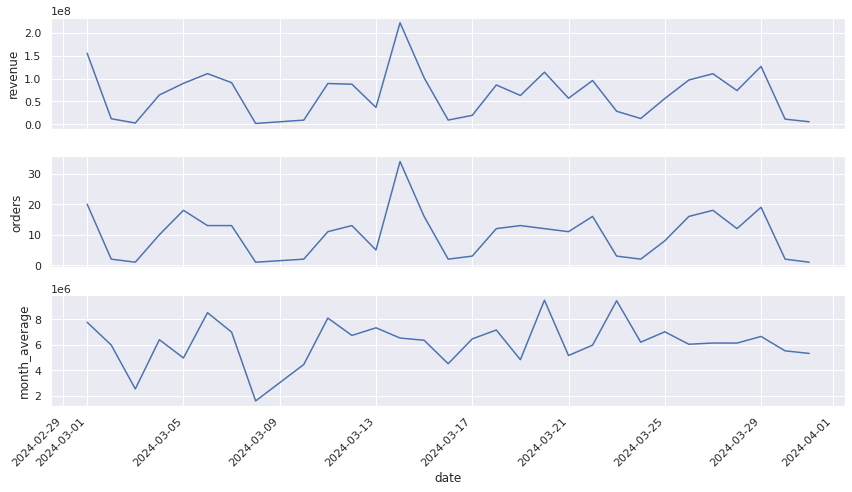

In [66]:
sns.set(font_scale = 1, rc = {'figure.figsize': (12,7)})
fig, axs = plt.subplots(3,1, sharex=True) #используют одну ось x
sns.lineplot(data=df_report_by_date, x="date", y="revenue", ax=axs[0], markers = True)
plt.xticks(rotation=45, ha='right')
sns.lineplot(data=df_report_by_date, x="date", y="orders", ax=axs[1], markers = True)
sns.lineplot(data=df_report_by_date, x="date", y="month_average", ax=axs[2], markers = True)
plt.tight_layout()

**Выводы:**

- число заказов и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день число заказов выросло, то выручка может упасть, и наоборот: число заказов упало — в этот же день выручка выросла)
- средний чек и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день средний чек вырос, то выручка может упасть, и наоборот: средний чек упал — в этот же день выручка выросла)
- в день с наибольшим числом заказов средний чек не показывает максимальное значение
- с течением времени выручка то увеличивается, то уменьшается
- на протяжении всего месяца уровень средного чека то увеличивается, то уменьшается

### Анализирую интерес клиентов к брендам

**Задание:** К вам снова обратился руководитель отдела продаж. Он хочет разобраться, какие бренды востребованы среди клиентов, а какие — нет. На основе данных о названиях товаров в датафрейме `df_full` создайте новую колонку `brand`, где будет только название бренда. 


Необходимо понять, какими брендами интересуются клинеты, сколько таких брендов. Вне зависимости от статуса заказа.

In [68]:
df_full.head(10)

,product_id,name,price,category,order_id,quantity,manager,date,client_id,status,currency_rate,price_rub,revenue
0,12,"ART, DJPREII",41.58,Предусилитель,NXEB-21130782,5,Владимир Ударников,2024-03-15,14,confirmed,91.6359,3810.220722,19051.103610
1,248,"Douk Audio, P2",64.90,Предусилитель,LGQV-84115251,3,Алексей Саксофонов,2024-03-15,56,confirmed,91.6359,5947.169910,17841.509730
2,1018,"NAD, C 165BEE",705.00,Предусилитель,RFFA-91836327,2,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,64603.309500,129206.619000
3,1026,"Nobsound, NS-10G PRO",61.27,Предусилитель,FTNR-81877309,4,Максим Барабанов,2024-03-15,78,canceled,91.6359,5614.531593,22458.126372
4,470,"Heco, Studio Pro 30",155.77,Конденсаторный микрофон,GPXU-57197024,15,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,14274.124143,214111.862145
5,846,"MAONO, AU-PM421",30.00,Конденсаторный микрофон,JLGT-93610493,8,Екатерина Тарелкина,2024-03-15,83,confirmed,91.6359,2749.077000,21992.616000
6,1302,"Rode, NT1-A",191.86,Конденсаторный микрофон,RFFA-91836327,17,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,17581.263774,298881.484158
7,1353,"Sennheiser, ME 2-II",115.72,Конденсаторный микрофон,GPXU-57197024,8,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,10604.106348,84832.850784
8,1359,"Sennheiser, E 614",185.91,Конденсаторный микрофон,GAVM-06068589,11,Маргарита Камертонова,2024-03-15,11,confirmed,91.6359,17036.030169,187396.331859
9,1359,"Sennheiser, E 614",185.91,Конденсаторный микрофон,FTNR-81877309,21,Максим Барабанов,2024-03-15,78,canceled,91.6359,17036.030169,357756.633549


In [69]:
df_full['brand'] = df_full.name.apply(lambda x: x.split(',')[0])
df_full.head(10)

,product_id,name,price,category,order_id,quantity,manager,date,client_id,status,currency_rate,price_rub,revenue,brand
0,12,"ART, DJPREII",41.58,Предусилитель,NXEB-21130782,5,Владимир Ударников,2024-03-15,14,confirmed,91.6359,3810.220722,19051.103610,ART
1,248,"Douk Audio, P2",64.90,Предусилитель,LGQV-84115251,3,Алексей Саксофонов,2024-03-15,56,confirmed,91.6359,5947.169910,17841.509730,Douk Audio
2,1018,"NAD, C 165BEE",705.00,Предусилитель,RFFA-91836327,2,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,64603.309500,129206.619000,NAD
3,1026,"Nobsound, NS-10G PRO",61.27,Предусилитель,FTNR-81877309,4,Максим Барабанов,2024-03-15,78,canceled,91.6359,5614.531593,22458.126372,Nobsound
4,470,"Heco, Studio Pro 30",155.77,Конденсаторный микрофон,GPXU-57197024,15,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,14274.124143,214111.862145,Heco
5,846,"MAONO, AU-PM421",30.00,Конденсаторный микрофон,JLGT-93610493,8,Екатерина Тарелкина,2024-03-15,83,confirmed,91.6359,2749.077000,21992.616000,MAONO
6,1302,"Rode, NT1-A",191.86,Конденсаторный микрофон,RFFA-91836327,17,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,17581.263774,298881.484158,Rode
7,1353,"Sennheiser, ME 2-II",115.72,Конденсаторный микрофон,GPXU-57197024,8,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,10604.106348,84832.850784,Sennheiser
8,1359,"Sennheiser, E 614",185.91,Конденсаторный микрофон,GAVM-06068589,11,Маргарита Камертонова,2024-03-15,11,confirmed,91.6359,17036.030169,187396.331859,Sennheiser
9,1359,"Sennheiser, E 614",185.91,Конденсаторный микрофон,FTNR-81877309,21,Максим Барабанов,2024-03-15,78,canceled,91.6359,17036.030169,357756.633549,Sennheiser


In [70]:
df_full['brand'].nunique()

121

**Вывод:** клиенты инетерсовались товарами 121 бренда.

## Бренд с наибольшей выручкой

Считаю, какую выручку принес каждый бренд и в скольких подтвержденных заказах были товары этого бренда.

In [71]:
df_full.groupby('brand', as_index = False).revenue.sum().sort_values('revenue', ascending = False)

,brand,revenue
46,JBL,3.080112e+08
43,Heco,2.632046e+08
53,Klipsch,2.205107e+08
120,Yamaha,1.798673e+08
49,KEF,1.619835e+08
...,...,...
88,SMSL,3.841799e+04
8,AudioSource,3.388167e+04
40,Fosi Audio,3.129419e+04
18,Bravo Audio,2.405086e+04


In [72]:
df_full.query("status == 'confirmed'") \
.groupby('brand', as_index = False) \
.order_id.nunique() \
.sort_values('order_id', ascending = False)

,brand,order_id
46,JBL,264
43,Heco,229
120,Yamaha,218
53,Klipsch,205
62,Magnat,154
...,...,...
19,Bryston,1
24,Creative,1
47,JVC,1
103,TCL,1


**Наибольшую выручку приносит бренд JBL. Товары данного бренда присутсвуют в 264 подтвержденных заказов.**

## Бренды, которые редко попадают в заказы

У одних брендов большинство товаров востребовано клиентами, а у других — клиенты заказывают только небольшую часть товаров. Необходимо понять, какие позиции брендов редко поподают в заказ и есть ли смысл их размещать на сайте компании или их лучше убрать.

Определим, какие товары из имеющихся в продаже хоть раз заказывали, а какие — нет. 
1. Собираю список из перечня уникальных идентификаторов товаров, которые встречаются в датафрейме `df_confirmed`.
2. Для каждого товара в датафрейме `df_products` определяю, был ли этот товар в списке заказанных товаров в этом месяце или нет.
3. Создаю новую колонку `is_in_orders` и заполняю её соответственно значениями `yes` или `no` для каждого товара.

In [73]:
df_confirmed.head(5)

,product_id,name,price,category,order_id,quantity,manager,date,client_id,status,currency_rate,price_rub,revenue
0,12,"ART, DJPREII",41.58,Предусилитель,NXEB-21130782,5,Владимир Ударников,2024-03-15,14,confirmed,91.6359,3810.220722,19051.103610
1,248,"Douk Audio, P2",64.90,Предусилитель,LGQV-84115251,3,Алексей Саксофонов,2024-03-15,56,confirmed,91.6359,5947.169910,17841.509730
2,1018,"NAD, C 165BEE",705.00,Предусилитель,RFFA-91836327,2,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,64603.309500,129206.619000
4,470,"Heco, Studio Pro 30",155.77,Конденсаторный микрофон,GPXU-57197024,15,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,14274.124143,214111.862145
5,846,"MAONO, AU-PM421",30.00,Конденсаторный микрофон,JLGT-93610493,8,Екатерина Тарелкина,2024-03-15,83,confirmed,91.6359,2749.077000,21992.616000


In [74]:
products_in_orders = df_confirmed.product_id.unique()

In [82]:
is_in_orders = []
for prod in df_products.product_id.values:
    if prod in products_in_orders:
        is_in_orders.append('yes')
    else:
        is_in_orders.append('no')

In [84]:
df_products['is_in_orders'] = is_in_orders

In [86]:
df_products['is_in_orders'].value_counts()

yes    1180
no      497
Name: is_in_orders, dtype: int64

In [87]:
df_products.head(5)

,product_id,name,price,category,is_in_orders
0,12,"ART, DJPREII",41.58,Предусилитель,yes
1,66,"Behringer, Microphono PP400",20.76,Предусилитель,no
2,114,"Cambridge Audio, Azur 851N",1275.03,Предусилитель,no
3,248,"Douk Audio, P2",64.90,Предусилитель,yes
4,340,"Emotiva, BasX PT-100",246.89,Предусилитель,no


**Вывод:** 1180 товаров были заказаны в марте, 497 - нет. Дальше необходимо понять, к каким брендам они относятся.

## Определяю, у каких брендов доля ни разу не заказанных товаров больше половины от всех продаваемых товаров бренда

Посмотрю на эти данные в разрезе по брендам. Смотрю, у каких брендов доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда. Бренды, которые представлены маленьким числом товаров (меньше 15), не смотрю, так как места на сайте они особо не занимают.

In [88]:
df_products['brand'] = df_products.name.apply(lambda x: x.split(',')[0])

In [92]:
brand_products = df_products \
.groupby(['brand', 'is_in_orders'], as_index = False) \
.product_id.nunique() \
.rename(columns = {'product_id': 'products'})

brand_products

,brand,is_in_orders,products
0,AKG,no,6
1,AKG,yes,5
2,ART,yes,1
3,ASUS,no,1
4,ASUS,yes,2
...,...,...,...
208,Xiaomi,yes,4
209,YAQIN,no,1
210,Yamaha,no,15
211,Yamaha,yes,91


In [100]:
brands_in_orders = brand_products.pivot(values = 'products', index = 'brand', columns = 'is_in_orders').fillna(0)\
.astype('int') \
.reset_index()

brands_in_orders

is_in_orders,brand,no,yes
0,AKG,6,5
1,ART,0,1
2,ASUS,1,2
3,Adam Audio,1,0
4,Amazon,0,4
...,...,...,...
141,Wharfedale,7,50
142,Xiaomi,0,4
143,YAQIN,1,0
144,Yamaha,15,91


In [104]:
brands_in_orders['product_num'] = brands_in_orders.no + brands_in_orders.yes
brands_in_orders = brands_in_orders.query('product_num > 15')
brands_in_orders

is_in_orders,brand,no,yes,product_num,share
17,Bose,6,15,21,0.29
32,Dali,49,18,67,0.73
36,Denon,7,34,41,0.17
39,Edifier,20,53,73,0.27
53,Harman Kardon,19,61,80,0.24
54,Heco,6,85,91,0.07
57,JBL,7,108,115,0.06
60,KEF,54,28,82,0.66
64,Klipsch,6,66,72,0.08
76,Magnat,21,71,92,0.23


In [105]:
brands_in_orders['share'] = round(brands_in_orders.no / brands_in_orders.product_num, 2)
brands_in_orders.sort_values('share', ascending = False)

/tmp/ipykernel_51/4224633458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brands_in_orders['share'] = round(brands_in_orders.no / brands_in_orders.product_num, 2)


is_in_orders,brand,no,yes,product_num,share
77,Marantz,19,3,22,0.86
32,Dali,49,18,67,0.73
94,Pioneer,70,33,103,0.68
60,KEF,54,28,82,0.66
89,Onkyo,9,21,30,0.30
17,Bose,6,15,21,0.29
39,Edifier,20,53,73,0.27
121,Sony,10,27,37,0.27
111,Sennheiser,20,56,76,0.26
53,Harman Kardon,19,61,80,0.24


Больше половины товаров никогда не были заказаны у 4 брендов: **Marantz, Dali, Pioneer, KEF**.

### Составляю отчет по продажам менеджеров

**Отчет по сделкам каждого менеджера**: сколько он оформил подтвержденных заказов и какую выручку они принесли. Смотрим в процентах: какой % выручки от общей выручки за месяц приходится на каждого менеджера, и какой % заказов от общего числа заказов. Результаты визуализированы.

In [106]:
df_full.head(10)

,product_id,name,price,category,order_id,quantity,manager,date,client_id,status,currency_rate,price_rub,revenue,brand
0,12,"ART, DJPREII",41.58,Предусилитель,NXEB-21130782,5,Владимир Ударников,2024-03-15,14,confirmed,91.6359,3810.220722,19051.103610,ART
1,248,"Douk Audio, P2",64.90,Предусилитель,LGQV-84115251,3,Алексей Саксофонов,2024-03-15,56,confirmed,91.6359,5947.169910,17841.509730,Douk Audio
2,1018,"NAD, C 165BEE",705.00,Предусилитель,RFFA-91836327,2,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,64603.309500,129206.619000,NAD
3,1026,"Nobsound, NS-10G PRO",61.27,Предусилитель,FTNR-81877309,4,Максим Барабанов,2024-03-15,78,canceled,91.6359,5614.531593,22458.126372,Nobsound
4,470,"Heco, Studio Pro 30",155.77,Конденсаторный микрофон,GPXU-57197024,15,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,14274.124143,214111.862145,Heco
5,846,"MAONO, AU-PM421",30.00,Конденсаторный микрофон,JLGT-93610493,8,Екатерина Тарелкина,2024-03-15,83,confirmed,91.6359,2749.077000,21992.616000,MAONO
6,1302,"Rode, NT1-A",191.86,Конденсаторный микрофон,RFFA-91836327,17,Антон Скрипкин,2024-03-15,59,confirmed,91.6359,17581.263774,298881.484158,Rode
7,1353,"Sennheiser, ME 2-II",115.72,Конденсаторный микрофон,GPXU-57197024,8,Анастасия Дудкина,2024-03-15,78,confirmed,91.6359,10604.106348,84832.850784,Sennheiser
8,1359,"Sennheiser, E 614",185.91,Конденсаторный микрофон,GAVM-06068589,11,Маргарита Камертонова,2024-03-15,11,confirmed,91.6359,17036.030169,187396.331859,Sennheiser
9,1359,"Sennheiser, E 614",185.91,Конденсаторный микрофон,FTNR-81877309,21,Максим Барабанов,2024-03-15,78,canceled,91.6359,17036.030169,357756.633549,Sennheiser


In [114]:
managers_res = df_confirmed.groupby('manager', as_index = False) \
.aggregate({'revenue': 'sum',
          'order_id': 'nunique'}) \
.sort_values('revenue', ascending = False)

In [115]:
overall_revenue = managers_res.revenue.sum()
orders = managers_res.order_id.sum()

In [117]:
managers_res['revenue_share'] = round((managers_res['revenue'] / overall_revenue) * 100, 2)
managers_res['orders_share'] = round((managers_res['order_id'] / orders) * 100, 2)

managers_res

,manager,revenue,order_id,revenue_share,orders_share
9,Маргарита Камертонова,3.473886e+08,48,17.04,15.53
4,Виктор Тромбонов,3.188999e+08,50,15.65,16.18
8,Максим Барабанов,2.401478e+08,40,11.78,12.94
5,Владимир Ударников,2.084865e+08,31,10.23,10.03
0,Алексей Саксофонов,1.953435e+08,27,9.58,8.74
7,Ксения Балалайкина,1.817621e+08,27,8.92,8.74
6,Екатерина Тарелкина,1.781576e+08,28,8.74,9.06
10,Надежда Гармошкина,1.347836e+08,21,6.61,6.80
1,Анастасия Дудкина,1.234504e+08,20,6.06,6.47
2,Антон Скрипкин,5.150268e+07,7,2.53,2.27


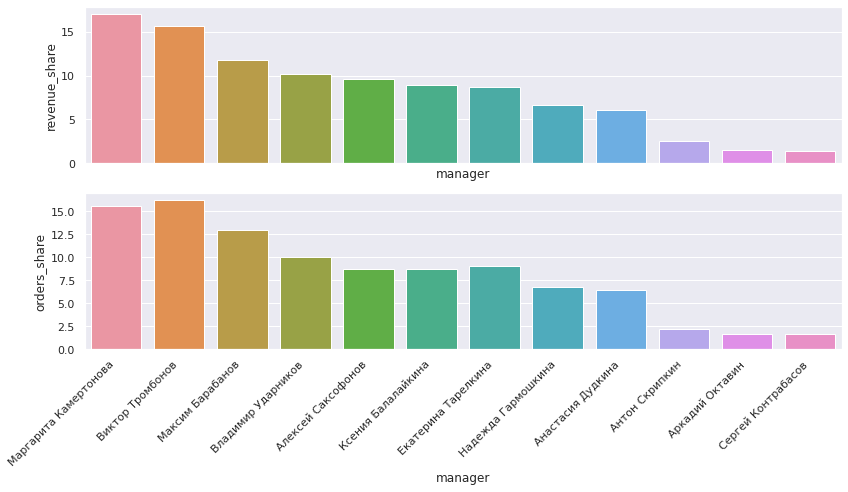

In [133]:
fig,axs = plt.subplots(2, 1, sharex=True)
sns.barplot(data = managers_res, x = 'manager', y = 'revenue_share', ax = axs[0])
plt.xticks(rotation=45, ha='right')
sns.barplot(data = managers_res, x = 'manager', y = 'orders_share', ax = axs[1])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

**Выводы:**
- Лучшим менеджером по % выручки стала Маргарита Камертонова
- Худшие показатели у Сергея Контрабасова
- В этом месяце нельзя выделить явную пятерку лидеров по % выручки, которые сильно оторвались от остальных
- Лидер по % заказов реализовал более 16% заказов
- Антон Скрипкин, Аркадий Октавин, Сергей Контрабасов продемонстрировали самые плохие показатели, которые радикально меньше по сравнению с другими менеджерами.

## Итоги

В рамках проекта я провела анализ продаж музыкальных товаров:
- Провела работу с неструктурированными данными, собрана информация из разных источников и созданы датасеты для анализа.
- Определила дни с аномальными показателями и выявила причины этих явлений.
- Посмотрела на ключевые метрики, такие как общая выручка, средний чек заказа, количество заказов. Проанализировала их изменения в динамике.
- Выявила наиболее прибыльные для продажи бренды, а также товары, которые наиболее востребованы среди покупателей.
- Выявила бренды, у которых больше половины товаров никогда не заказывались. Возможно, от их продажи на маркетплейсе есть смысл отказаться, так как они перегружают маркетплейс.
